In [1]:
# Cell 1: Imports and Setup
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import quantus
import h5py
import os

2024-07-16 22:48:17.483603: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2024-07-16 22:48:17.503918: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-07-16 22:48:17.519532: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-07-16 22:48:17.524342: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-07-16 22:48:17.537841: I tensorflow/core/platform/cpu_feature_guar

In [3]:

# Cell 2: Load Model
model = tf.keras.models.load_model('results_50E/alexnet_audio_model.h5')


In [4]:
# Cell 3: Data Loading Function
def load_test_data(data_path, num_samples=8):
    X = []
    y = []
    for root, _, files in os.walk(data_path):
        for file in files:
            if file.startswith('AlexNet') and file.endswith('.hdf5'):
                file_path = os.path.join(root, file)
                with h5py.File(file_path, 'r') as f:
                    X.append(f['data'][:])
                    y.append(f['label'][:, 0])
                if len(X) >= num_samples:
                    break
        if len(X) >= num_samples:
            break
    return np.concatenate(X, axis=0)[:num_samples], np.array(y)[:num_samples]


In [7]:
# Cell 4: Load and Preprocess Data
data_path = '/home/mqa887/tmp/audiomnist/AudioMNIST-master'
x_batch, y_batch = load_test_data(data_path)
x_batch = (x_batch - np.mean(x_batch)) / np.std(x_batch)  # Normalize

# Reshape the input to match the model's expected input shape
x_batch = np.transpose(x_batch, (0, 2, 3, 1))  # Change from (batch, 1, 227, 227) to (batch, 227, 227, 1)

print("Input shape:", x_batch.shape)
print("Label shape:", y_batch.shape)

Input shape: (8, 227, 227, 1)
Label shape: (8, 1)


In [8]:
# Cell 5: Generate Predictions
y_pred = model.predict(x_batch).argmax(axis=1)
print("Predictions shape:", y_pred.shape)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step
Predictions shape: (8,)


In [9]:

# Cell 6: Generate Integrated Gradients Explanations
a_batch_ig = quantus.explain(model, x_batch, y_pred, method="IntegratedGradients")


/home/mqa887/.conda/envs/myvm/lib/python3.12/site-packages/quantus/functions/explanation_func.py:242: UserWarning: tf-explain library is being used for XAI attribution calculation. Consult with tf-explain documentation to find out the type of operations applied on the method output, i.e.  normalisation, taking the absolutevalue, etc.

  warnings.warn(


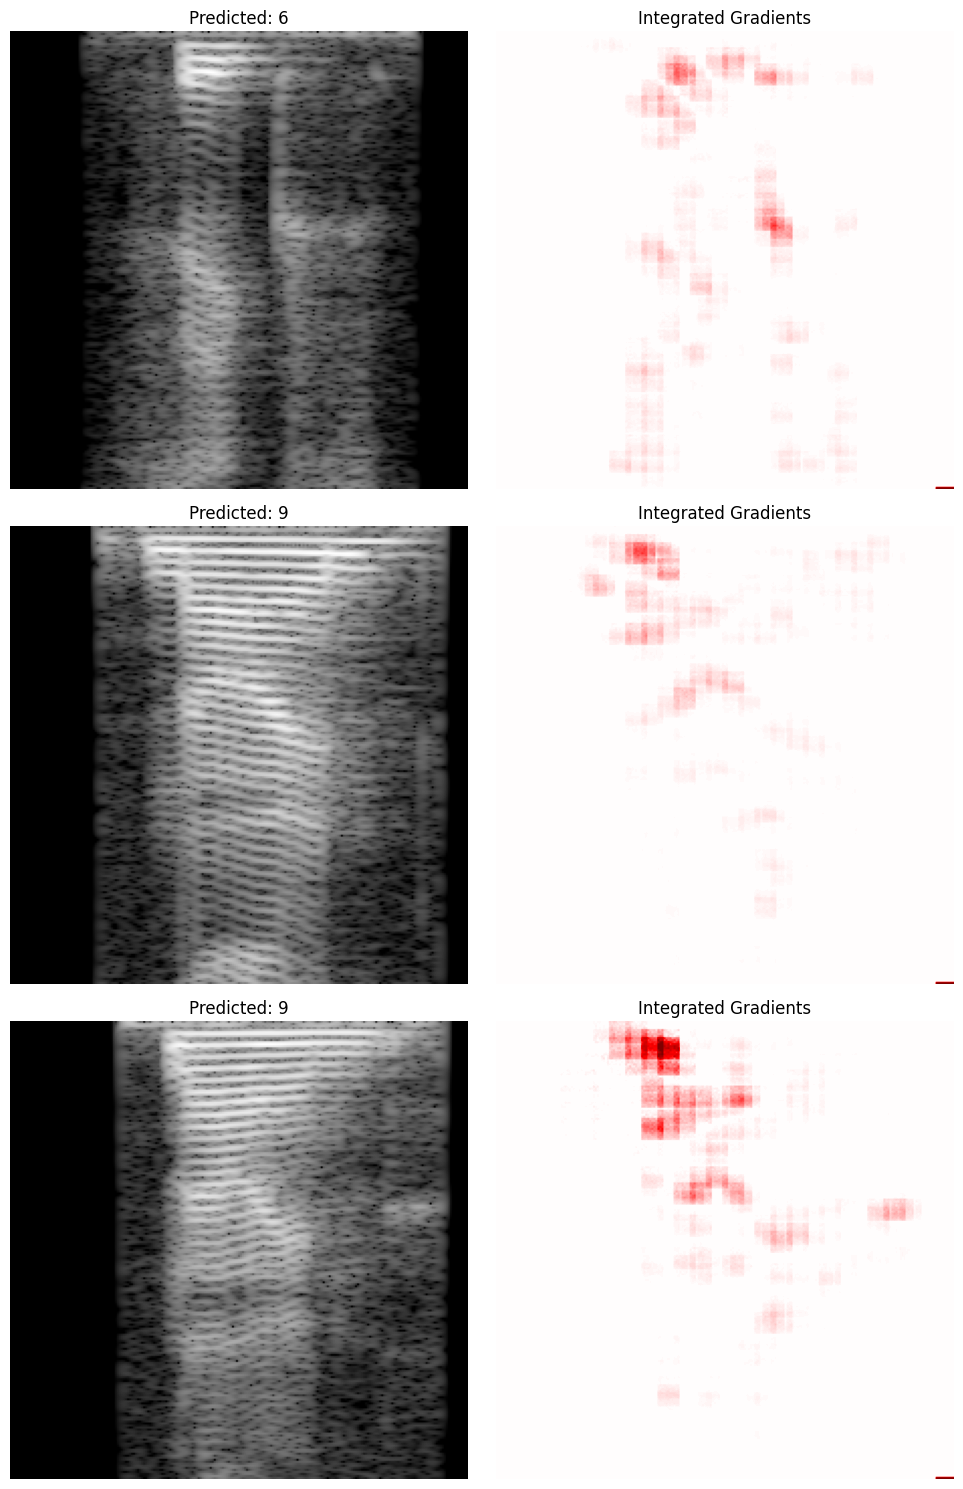

In [10]:
# Cell 7: Visualization Function
def visualize_explanations(x_batch, y_pred, a_batch, num_samples=3):
    fig, axes = plt.subplots(num_samples, 2, figsize=(10, 5*num_samples))
    for i in range(num_samples):
        axes[i, 0].imshow(x_batch[i].squeeze(), cmap='gray')
        axes[i, 0].set_title(f"Predicted: {y_pred[i]}")
        axes[i, 0].axis('off')
        axes[i, 1].imshow(a_batch[i], cmap='seismic', clim=(-1, 1))
        axes[i, 1].set_title("Integrated Gradients")
        axes[i, 1].axis('off')
    plt.tight_layout()
    plt.show()

# Cell 8: Visualize Integrated Gradients
visualize_explanations(x_batch, y_pred, a_batch_ig)


In [15]:
# Cell 9: Set up Quantus Metrics
metrics = [
    quantus.MaxSensitivity(),
    quantus.AvgSensitivity(),
    quantus.RelativeInputStability(),
    quantus.RelativeOutputStability(),
    quantus.RelativeRepresentationStability(),
]



In [17]:
import quantus

# Define an explanation function
def explain_func(model, inputs, targets, **kwargs):
    with tf.GradientTape() as tape:
        inputs = tf.convert_to_tensor(inputs, dtype=tf.float32)
        tape.watch(inputs)
        predictions = model(inputs)
        loss = tf.keras.losses.sparse_categorical_crossentropy(targets, predictions)
    gradients = tape.gradient(loss, inputs)
    return gradients.numpy()

# Cell 10: Evaluate Metrics
results = {}
metrics = [
    quantus.MaxSensitivity(nr_samples=10),
    quantus.AvgSensitivity(nr_samples=10),
    quantus.RelativeInputStability(nr_samples=10),
    quantus.RelativeOutputStability(nr_samples=10),
    quantus.RelativeRepresentationStability(nr_samples=10),
]

for metric in metrics:
    print(f"\nEvaluating {metric.__class__.__name__}:")
    print("x_batch shape:", x_batch.shape)
    print("y_pred shape:", y_pred.shape)
    print("a_batch_ig shape:", a_batch_ig.shape)
    
    # Add channel dimension to a_batch_ig if it's missing
    if a_batch_ig.ndim == 3:
        a_batch_ig = np.expand_dims(a_batch_ig, axis=-1)
    print("Updated a_batch_ig shape:", a_batch_ig.shape)
    
    try:
        # Get default parameters
        params = metric.get_params() if callable(getattr(metric, 'get_params', None)) else {}
        
        # Add explain_func to params
        params['explain_func'] = explain_func
        
        # Adjust parameters based on the metric
        if isinstance(metric, quantus.RelativeInputStability):
            params['layer_names'] = [model.layers[-1].name]  # Use the last layer
        elif isinstance(metric, quantus.RelativeRepresentationStability):
            params['layer_names'] = [layer.name for layer in model.layers if isinstance(layer, tf.keras.layers.Conv2D)]
        
        # Ensure the model has been called at least once
        _ = model(x_batch)
        
        score = metric(
            model=model,
            x_batch=x_batch,
            y_batch=y_pred,
            a_batch=a_batch_ig,
            **params
        )
        results[metric.__class__.__name__] = score
        print(f"Successfully evaluated {metric.__class__.__name__}")
    except Exception as e:
        print(f"Error evaluating {metric.__class__.__name__}: {str(e)}")
    
    print(f"Parameters used for {metric.__class__.__name__}:")
    print(params)
    print()

# Print results
for metric_name, score in results.items():
    print(f"{metric_name}: {score}")


Evaluating MaxSensitivity:
x_batch shape: (8, 227, 227, 1)
y_pred shape: (8,)
a_batch_ig shape: (8, 227, 227, 1)
Updated a_batch_ig shape: (8, 227, 227, 1)
Successfully evaluated MaxSensitivity
Parameters used for MaxSensitivity:
{'explain_func': <function explain_func at 0x7f2560544cc0>}


Evaluating AvgSensitivity:
x_batch shape: (8, 227, 227, 1)
y_pred shape: (8,)
a_batch_ig shape: (8, 227, 227, 1)
Updated a_batch_ig shape: (8, 227, 227, 1)
Successfully evaluated AvgSensitivity
Parameters used for AvgSensitivity:
{'explain_func': <function explain_func at 0x7f2560544cc0>}


Evaluating RelativeInputStability:
x_batch shape: (8, 227, 227, 1)
y_pred shape: (8,)
a_batch_ig shape: (8, 227, 227, 1)
Updated a_batch_ig shape: (8, 227, 227, 1)
Error evaluating RelativeInputStability: The layer sequential has never been called and thus has no defined input.
Parameters used for RelativeInputStability:
{'explain_func': <function explain_func at 0x7f2560544cc0>, 'layer_names': ['dense_2']}


Ev

In [18]:

# Cell 11: Print Results
print("Quantus Analysis Results:")
for metric, score in results.items():
    print(f"{metric}: {np.mean(score):.4f} ± {np.std(score):.4f}")


Quantus Analysis Results:
MaxSensitivity: 1.0000 ± 0.0000
AvgSensitivity: 1.0000 ± 0.0000


In [19]:

# Cell 12: Create and Display Results DataFrame
results_df = pd.DataFrame({metric: score for metric, score in results.items()})
results_df.describe()

,MaxSensitivity,AvgSensitivity
count,8.000000e+00,8.000000e+00
mean,1.000000e+00,1.000000e+00
std,9.729578e-08,7.563122e-08
min,1.000000e+00,1.000000e+00
25%,1.000000e+00,1.000000e+00
50%,1.000000e+00,1.000000e+00
75%,1.000000e+00,1.000000e+00
max,1.000000e+00,1.000000e+00


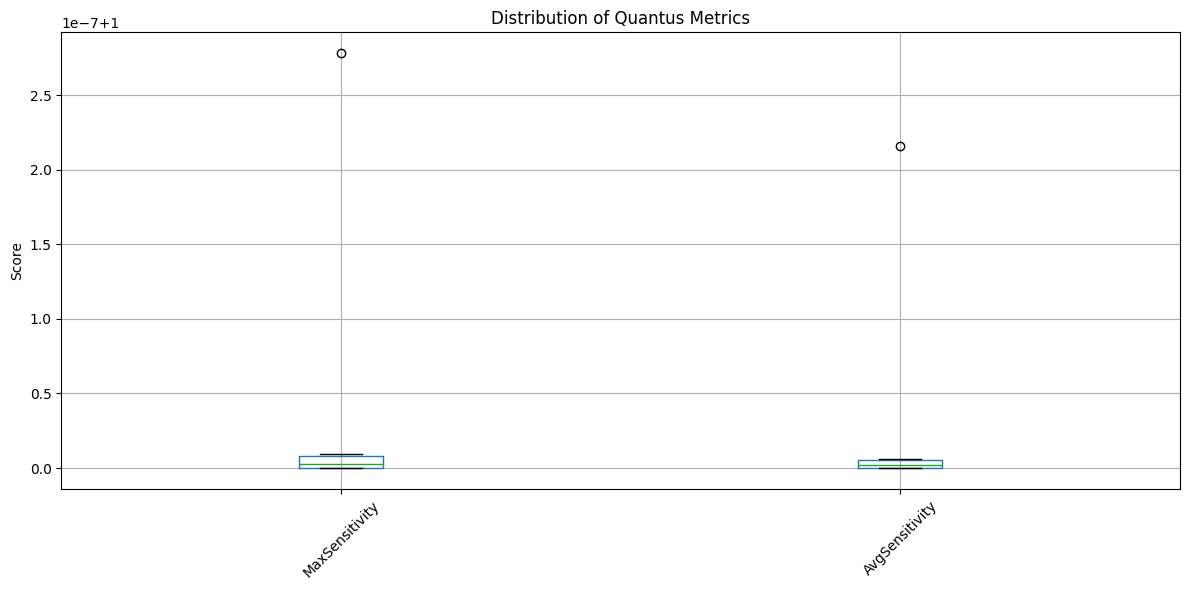

In [20]:
# Cell 13: Visualize Metric Distributions
plt.figure(figsize=(12, 6))
results_df.boxplot()
plt.title("Distribution of Quantus Metrics")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [21]:
# Cell 14: Generate Grad-CAM Explanations
a_batch_gradcam = quantus.explain(model, x_batch, y_pred, method="GradCAM")

# Cell 15: Visualize Grad-CAM Explanations
visualize_explanations(x_batch, y_pred, a_batch_gradcam, num_samples=3)


/home/mqa887/.conda/envs/myvm/lib/python3.12/site-packages/quantus/functions/explanation_func.py:242: UserWarning: tf-explain library is being used for XAI attribution calculation. Consult with tf-explain documentation to find out the type of operations applied on the method output, i.e.  normalisation, taking the absolutevalue, etc.

  warnings.warn(


AttributeError: 'Dense' object has no attribute 'output_shape'

In [ ]:
# Cell 16: Function to Compare Explanations
def compare_explanations(x_batch, y_pred, a_batch_ig, a_batch_gradcam, num_samples=3):
    fig, axes = plt.subplots(num_samples, 3, figsize=(15, 5*num_samples))
    for i in range(num_samples):
        axes[i, 0].imshow(x_batch[i].squeeze(), cmap='gray')
        axes[i, 0].set_title(f"Predicted: {y_pred[i]}")
        axes[i, 0].axis('off')
        axes[i, 1].imshow(a_batch_ig[i], cmap='seismic', clim=(-1, 1))
        axes[i, 1].set_title("Integrated Gradients")
        axes[i, 1].axis('off')
        axes[i, 2].imshow(a_batch_gradcam[i], cmap='jet', clim=(0, 1))
        axes[i, 2].set_title("Grad-CAM")
        axes[i, 2].axis('off')
    plt.tight_layout()
    plt.show()


# Cell 17: Compare Integrated Gradients and Grad-CAM
compare_explanations(x_batch, y_pred, a_batch_ig, a_batch_gradcam)

In [14]:
# Add this before the metrics evaluation loop
print("Model summary:")
model.summary()

print("\nInput shapes:")
print("x_batch shape:", x_batch.shape)
print("y_pred shape:", y_pred.shape)
print("a_batch_ig shape:", a_batch_ig.shape)

# Add this inside the loop, just before calling the metric
print(f"\nEvaluating {metric.__class__.__name__}:")
print("x_batch shape:", x_batch.shape)
print("y_pred shape:", y_pred.shape)
print("a_batch_ig shape:", a_batch_ig.shape)

Model summary:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 55, 55, 96)     │        11,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 27, 27, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 27, 27, 256)    │       614,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 13, 13, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 13, 13, 384)    │       885,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 13, 13, 384)    │     1,327,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 13, 13, 256)    │       884,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1024)           │     9,438,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1024)           │     1,049,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │        10,250 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,222,027 (54.25 MB)

 Trainable params: 14,222,026 (54.25 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1 (8.00 B)


Input shapes:
x_batch shape: (8, 227, 227, 1)
y_pred shape: (8,)
a_batch_ig shape: (8, 227, 227)

Evaluating MaxSensitivity:
x_batch shape: (8, 227, 227, 1)
y_pred shape: (8,)
a_batch_ig shape: (8, 227, 227)
